## Part A : Classical ML Pipeline

In [14]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from datasets import load_dataset 
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

In [11]:
dataset = load_dataset("stanfordnlp/imdb", split = "train")
df = pd.DataFrame(dataset).sample(5000, random_state = 42).reset_index(drop = True)
df

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

C:\Users\snaaf\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\snaaf\.cache\huggingface\hub\datasets--stanfordnlp--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/unsupervised-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 42.0MB            

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

,text,label
0,"Dumb is as dumb does, in this thoroughly unint...",0
1,I dug out from my garage some old musicals and...,1
2,After watching this movie I was honestly disap...,0
3,This movie was nominated for best picture but ...,1
4,Just like Al Gore shook us up with his painful...,1
...,...,...
4995,If you seen Rodney Dangerfield's previous movi...,0
4996,Anything that might have been potentially inte...,0
4997,That is quite an outdated movie which aims to ...,0
4998,"This is a comedy of morals, so occasionally a ...",1


In [13]:
print(df['label'].value_counts())

label
0    2515
1    2485
Name: count, dtype: int64


In [16]:
def clean_text(text):
    text = re.sub(r'<.*?>',' ',text)
    text = re.sub(r'[^a-zA-Z\s]','',text)
    text = text.lower().strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [17]:
X = df['clean_text']
y = df['label']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [22]:
vectorizer = TfidfVectorizer(max_features = 5000, ngram_range = (1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [23]:
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
y_pred = model.predict(X_test_tfidf)
compare = pd.DataFrame({
    "actual":y_test,
    "predicted":y_pred
})
print(compare)

      actual  predicted
3781       1          1
1828       0          0
3388       1          1
3258       0          1
4417       0          0
...      ...        ...
3263       1          1
1719       1          1
2932       1          1
3017       1          1
319        1          1

[1000 rows x 2 columns]


In [27]:
print("classification report:\n",classification_report(y_test,y_pred))

classification report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85       503
           1       0.85      0.85      0.85       497

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000



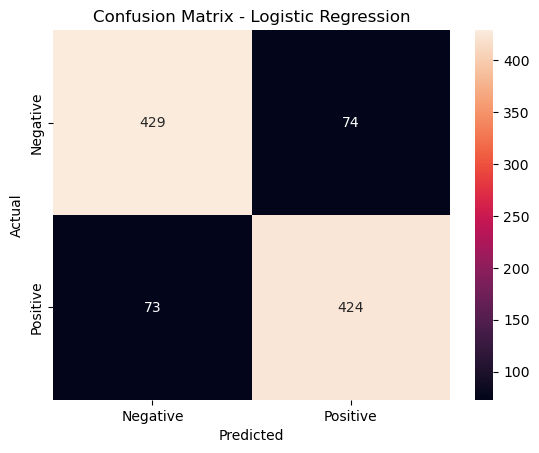

In [31]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', xticklabels = ['Negative','Positive'], yticklabels = ['Negative','Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Part B : Hugging Face transformer(pre-trained)

In [52]:
from transformers import pipeline
import numpy as np

In [38]:
classifier = pipeline("sentiment-analysis", model = "distilbert-base-uncased-finetuned-sst-2-english")
print(classifier.tokenizer.model_max_length)  

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

C:\Users\snaaf\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\snaaf\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

512


In [39]:
raw_pred = classifier(X_test.tolist(), truncation = True, max_length = 512)

In [40]:
y_pred_transformer = [1 if pred['label'] == 'POSITIVE' else 0 for pred in raw_pred]

In [45]:
cr = classification_report(y_test, y_pred_transformer, target_names = ['Negative','Positive'])
print(cr)

              precision    recall  f1-score   support

    Negative       0.82      0.95      0.88       503
    Positive       0.94      0.78      0.85       497

    accuracy                           0.87      1000
   macro avg       0.88      0.87      0.87      1000
weighted avg       0.88      0.87      0.87      1000



## Part C : Comparison [Inference time]

In [56]:
import time
sample = X_test.iloc[:100]
sample_tfidf = vectorizer.transform(sample)

In [48]:
start_time = time.time()
_ = model.predict(sample_tfidf)
LR_time = time.time() - start_time

In [54]:
start_time = time.time()
_ = classifier(sample.tolist(), truncation = True, max_length = 512)
transformer_time = time.time() - start_time

In [55]:
print("Logistic Regression time per 100 samples:", LR_time)
print("DistilBERT Transformer time per 100 samples:",transformer_time)

Logistic Regression time per 100 samples: 0.0005745887756347656
DistilBERT Transformer time per 100 samples: 11.95075535774231
